In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load
df = pd.read_csv('cardekho_dataset.csv')
df = df.drop(columns=['Unnamed: 0', 'car_name', 'model'])

# One-hot encode
df = pd.get_dummies(df, columns=['brand', 'seller_type', 'fuel_type',
                                  'transmission_type'], drop_first=True)

# Separate features and target
X = df.drop(columns=['selling_price'])
y = df['selling_price']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale numeric features
numeric_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f'Train: {X_train.shape[0]} rows, {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]} rows')
print('Data prep complete ✅')

Train: 12328 rows, 44 features
Test:  3083 rows
Data prep complete ✅


In [4]:
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

y_train_pred = ols_model.predict(X_train)
y_test_pred = ols_model.predict(X_test)

ols_train_mae = mean_absolute_error(y_train, y_train_pred)
ols_test_mae = mean_absolute_error(y_test, y_test_pred)
ols_train_r2 = r2_score(y_train, y_train_pred)
ols_test_r2 = r2_score(y_test, y_test_pred)

print('=' * 55)
print(f'{"OLS Baseline":<15} {"Train":>15} {"Test":>15}')
print('=' * 55)
print(f'{"MAE":<15} {"₹{:,.0f}".format(ols_train_mae):>15} {"₹{:,.0f}".format(ols_test_mae):>15}')
print(f'{"R²":<15} {ols_train_r2:>15.4f} {ols_test_r2:>15.4f}')
print('=' * 55)
gap = ols_train_r2 - ols_test_r2
print(f'\nTrain-Test Gap (R²): {gap:.4f}')
print('→ Overfitting detected!' if gap > 0.05 else '→ Gap is small.')

OLS Baseline              Train            Test
MAE                    ₹199,220        ₹212,761
R²                       0.8016          0.7360

Train-Test Gap (R²): 0.0656
→ Overfitting detected!


Ridge Model with default Alpha

In [5]:
ridge_default = Ridge(alpha = 1.0)
ridge_default.fit(X_train, y_train)

y_tr = ridge_default.predict(X_train)

y_te = ridge_default.predict(X_test)

print('=' * 55)
print(f'{"Ridge (α=1.0)":<15} {"Train":>15} {"Test":>15}')
print('=' * 55)
print(f'{"MAE":<15} {"₹{:,.0f}".format(mean_absolute_error(y_train, y_tr)):>15} {"₹{:,.0f}".format(mean_absolute_error(y_test, y_te)):>15}')
print(f'{"R²":<15} {r2_score(y_train, y_tr):>15.4f} {r2_score(y_test, y_te):>15.4f}')
print('=' * 55)

Ridge (α=1.0)             Train            Test
MAE                    ₹210,894        ₹220,956
R²                       0.7642          0.7366


In [25]:
alphas = [0.001, 0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000, 5000, 100000]

print('Ridge: Cross-Validation Scores Across Alpha Values')
print('=' * 65)
print(f'{"Alpha":>10}  {"CV R² (mean)":>15}  {"± Std":>10}  {"CV MAE":>15}')
print('-' * 65)


ridge_results = []
for alpha in alphas:
    pipe = Pipeline([
        ('scaler', ColumnTransformer([('num', StandardScaler(), numeric_cols)], remainder='passthrough')),
        ('model', Ridge(alpha=alpha))
    ])
    cv_r2 = cross_val_score(pipe, X, y, cv=5, scoring='r2')
    cv_mae = -cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_absolute_error')
    ridge_results.append({'alpha': alpha, 'cv_r2_mean': cv_r2.mean(), 'cv_mae_mean': cv_mae.mean()})
    print(f'{alpha:>10}  {cv_r2.mean():>15.4f}  {"₹{:,.0f}".format(cv_mae.mean()):>15}')


Ridge: Cross-Validation Scores Across Alpha Values
     Alpha     CV R² (mean)       ± Std           CV MAE
-----------------------------------------------------------------
     0.001           0.6812         ₹209,900
      0.01           0.6813         ₹210,009
       0.1           0.6818         ₹211,070
         1           0.6823         ₹217,913
        10           0.6775         ₹230,477
        50           0.6680         ₹239,876
       100           0.6632         ₹243,254
       200           0.6589         ₹245,546
       500           0.6536         ₹246,063
      1000           0.6483         ₹243,577
      5000           0.6088         ₹231,871
    100000           0.2044         ₹375,414


In [27]:
best_ridge = max(ridge_results, key=lambda x: x['cv_r2_mean'])
print(f'\n✅ Best Ridge alpha: {best_ridge["alpha"]} (CV R² = {best_ridge["cv_r2_mean"]:.4f})')


✅ Best Ridge alpha: 1 (CV R² = 0.6823)


In [28]:
ridge_results

[{'alpha': 0.001,
  'cv_r2_mean': np.float64(0.6811839510155406),
  'cv_mae_mean': np.float64(209899.74697461133)},
 {'alpha': 0.01,
  'cv_r2_mean': np.float64(0.6812508156560501),
  'cv_mae_mean': np.float64(210009.37056330283)},
 {'alpha': 0.1,
  'cv_r2_mean': np.float64(0.6817709279986819),
  'cv_mae_mean': np.float64(211069.99954651884)},
 {'alpha': 1,
  'cv_r2_mean': np.float64(0.6822641506904409),
  'cv_mae_mean': np.float64(217912.69603829816)},
 {'alpha': 10,
  'cv_r2_mean': np.float64(0.6774598587844035),
  'cv_mae_mean': np.float64(230477.15443456368)},
 {'alpha': 50,
  'cv_r2_mean': np.float64(0.667993937245801),
  'cv_mae_mean': np.float64(239876.19835232664)},
 {'alpha': 100,
  'cv_r2_mean': np.float64(0.6631872809981146),
  'cv_mae_mean': np.float64(243253.66683519236)},
 {'alpha': 200,
  'cv_r2_mean': np.float64(0.6588843332223903),
  'cv_mae_mean': np.float64(245546.0392805702)},
 {'alpha': 500,
  'cv_r2_mean': np.float64(0.6535726018464266),
  'cv_mae_mean': np.float64

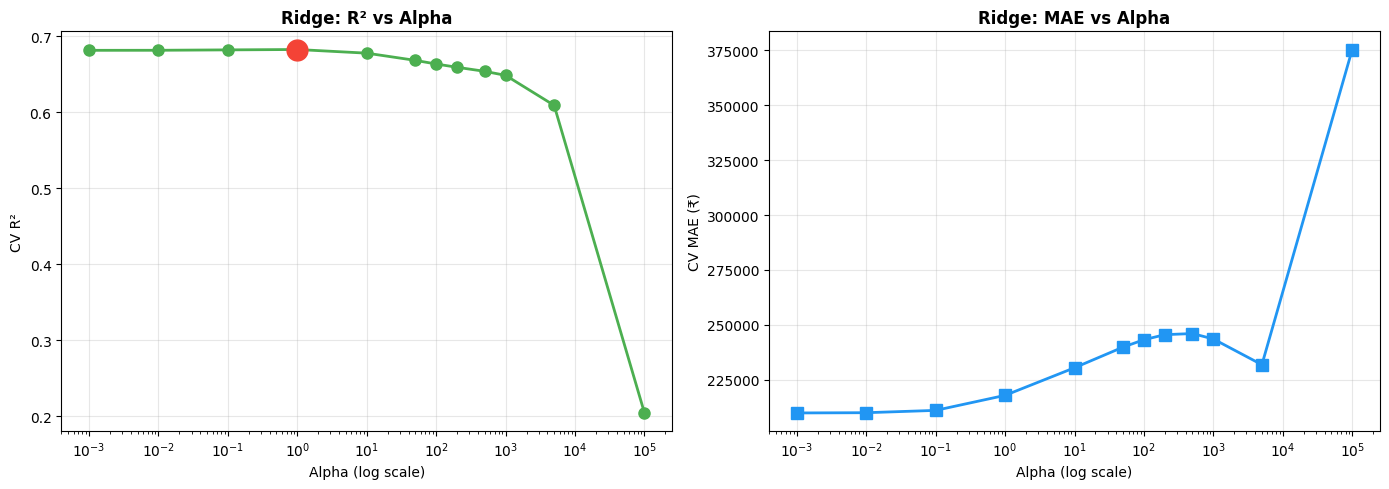

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

alphas_plot = [r['alpha'] for r in ridge_results]
r2_means = [r['cv_r2_mean'] for r in ridge_results]
mae_means = [r['cv_mae_mean'] for r in ridge_results]

ax = axes[0]
ax.plot(alphas_plot, r2_means, 'o-', color='#4CAF50', linewidth=2, markersize=8)
best_idx = r2_means.index(max(r2_means))
ax.plot(alphas_plot[best_idx], r2_means[best_idx], 'o', color='#F44336', markersize=15, zorder=6)
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('CV R²')
ax.set_title('Ridge: R² vs Alpha', fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(alphas_plot, mae_means, 's-', color='#2196F3', linewidth=2, markersize=8)
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('CV MAE (₹)')
ax.set_title('Ridge: MAE vs Alpha', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
alphas = [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000, 5000, 10000]

print('Ridge: Cross-Validation Scores Across Alpha Values')
print('=' * 55)
print(f'{"Alpha":>10}  {"CV R² (mean)":>15}  {"CV MAE":>15}')
print('-' * 55)

ridge_results = []
for alpha in alphas:
    pipe = Pipeline([
        ('scaler', ColumnTransformer([('num', StandardScaler(), numeric_cols)], remainder='passthrough')),
        ('model', Lasso(alpha=alpha))
    ])
    cv_r2 = cross_val_score(pipe, X, y, cv=5, scoring='r2')
    cv_mae = -cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_absolute_error')

    ridge_results.append({'alpha': alpha, 'cv_r2_mean': cv_r2.mean(), 'cv_mae_mean': cv_mae.mean()})
    print(f'{alpha:>10}  {cv_r2.mean():>15.4f}  {"₹{:,.0f}".format(cv_mae.mean()):>15}')


Ridge: Cross-Validation Scores Across Alpha Values
     Alpha     CV R² (mean)           CV MAE
-------------------------------------------------------
     0.001           0.6812         ₹209,887
      0.01           0.6812         ₹209,888
       0.1           0.6812         ₹209,888
         1           0.6812         ₹209,898
        10           0.6812         ₹210,006
        50           0.6813         ₹210,621
       100           0.6811         ₹211,492
       500           0.6795         ₹220,367
      1000           0.6729         ₹231,737
      5000           0.6480         ₹255,360
     10000           0.6400         ₹260,706
